# Functional Propagation

This notebook contains code to generate eggnog-mapper annotations and GAF file from the GO annotations. This will then be used with HOGPROP to annotate the ancestral genomes in our mini dataset.

In [38]:
mini_dataset_path = '/work/FAC/FBM/DBC/cdessim2/default/summer_school2026/mini_dataset'

## Run eggnog-mapper

Before we can perform functional enrichment analyses, we need functional annotations for our proteins. In this step, we will use eggNOG-mapper to assign functional annotations based on orthology relationships.

For demonstration purposes, we will first run eggNOG-mapper on a small subset of proteins. We will then run the same analysis on all proteomes using a SLURM job array.

### Running eggNOG-mapper on a small example

In [10]:
#where are we
%%bash
pwd

/work/FAC/FBM/DBC/cdessim2/default/summer_school2026/mini_dataset/function_test/step1_annotation


In [17]:
from Bio import SeqIO

input_fasta = os.path.join(mini_dataset_path, "proteome", "Gallus_gallus.fa")
output_fasta = "test_10_proteins.fa"

records = []

for i, record in enumerate(SeqIO.parse(input_fasta, "fasta")):
    records.append(record)
    if i == 9:
        break

SeqIO.write(records, output_fasta, "fasta")

print(f"Wrote {len(records)} proteins")

Wrote 10 proteins


In [15]:
EGGNOG_DATA_DIR = mini_dataset_path + "/function_test/step1_annotation/eggnog/eggnog_db"
EGGNOG_DATA_DIR

'/work/FAC/FBM/DBC/cdessim2/default/summer_school2026/mini_dataset/function_test/step1_annotation/eggnog/eggnog_db'

In [55]:
#Run eggNOG-mapper

import subprocess

EGGNOG_DATA_DIR = mini_dataset_path + "/function_test/step1_annotation/eggnog/eggnog_db"

cmd = [
    "emapper.py",
    "-i", "test_10_proteins.fa",
    "--itype", "proteins",
    "-o", "test_annotation",
    "--data_dir", EGGNOG_DATA_DIR,
    "--tax_scope", "Vertebrata",
    "--cpu", "8"
]

subprocess.run(cmd, check=True)

#  emapper-2.1.13
# emapper.py  -i test_10_proteins.fa --itype proteins -o test_annotation --data_dir /work/FAC/FBM/DBC/cdessim2/default/summer_school2026/mini_dataset/function_test/step1_annotation/eggnog/eggnog_db --tax_scope Vertebrata --cpu 8
Output files detected in disk. Use --resume or --override to continue


CalledProcessError: Command '['emapper.py', '-i', 'test_10_proteins.fa', '--itype', 'proteins', '-o', 'test_annotation', '--data_dir', '/work/FAC/FBM/DBC/cdessim2/default/summer_school2026/mini_dataset/function_test/step1_annotation/eggnog/eggnog_db', '--tax_scope', 'Vertebrata', '--cpu', '8']' returned non-zero exit status 1.

In [49]:
#examine results

import pandas as pd

columns = ['#query', 'seed_ortholog', 'evalue', 'score', 'eggNOG_OGs',
           'max_annot_lvl', 'COG_category', 'Description', 'Preferred_name', 'GOs',
           'EC', 'KEGG_ko', 'KEGG_Pathway', 'KEGG_Module', 'KEGG_Reaction',
           'KEGG_rclass', 'BRITE', 'KEGG_TC', 'CAZy', 'BiGG_Reaction', 'PFAMs']

test_df = pd.read_csv(
    "test_annotation.emapper.annotations",
    sep="\t",
    comment="#",
    header=None,
    names=columns
)

test_df

,#query,seed_ortholog,evalue,score,eggNOG_OGs,max_annot_lvl,COG_category,Description,Preferred_name,GOs,...,KEGG_ko,KEGG_Pathway,KEGG_Module,KEGG_Reaction,KEGG_rclass,BRITE,KEGG_TC,CAZy,BiGG_Reaction,PFAMs
0,GALGAL_R08064,9031.ENSGALP00000000002,0.000000e+00,1319.0,"28KPB@1|root,2QT63@2759|Eukaryota,38EQ0@33154|...",33208|Metazoa,S,Innexin,PANX2,"GO:0002931,GO:0003674,GO:0005215,GO:0005243,GO...",...,ko:K20857,-,-,-,-,"ko00000,ko02000","1.A.25.2.2,1.A.25.2.3",-,-,Innexin
1,GALGAL_R08065,9031.ENSGALP00000000795,4.950000e-93,272.0,"KOG2032@1|root,KOG2032@2759|Eukaryota,3APXZ@33...",33208|Metazoa,S,maestro heat-like repeat-containing protein fa...,-,-,...,-,-,-,-,-,-,-,-,-,-
2,GALGAL_R08066,9031.ENSGALP00000035827,3.620000e-88,275.0,"KOG2032@1|root,KOG2032@2759|Eukaryota,39XJ0@33...",33208|Metazoa,S,family member 2A,MROH2A,-,...,-,-,-,-,-,-,-,-,-,-
3,GALGAL_R08067,9031.ENSGALP00000035827,1.070000e-83,264.0,"KOG2032@1|root,KOG2032@2759|Eukaryota,39XJ0@33...",33208|Metazoa,S,family member 2A,MROH2A,-,...,-,-,-,-,-,-,-,-,-,-
4,GALGAL_R08068,9031.ENSGALP00000035827,1.370000e-84,266.0,"KOG2032@1|root,KOG2032@2759|Eukaryota,39XJ0@33...",33208|Metazoa,S,family member 2A,MROH2A,-,...,-,-,-,-,-,-,-,-,-,-
5,GALGAL_R08069,9031.ENSGALP00000001227,0.000000e+00,1756.0,"2CN6C@1|root,2QU3U@2759|Eukaryota,38GGN@33154|...",33208|Metazoa,S,52 kDa repressor of the inhibitor of the prote...,PRKRIR,"GO:0000981,GO:0003674,GO:0003676,GO:0003677,GO...",...,-,-,-,-,-,-,-,-,-,"DUF4371,Dimer_Tnp_hAT,THAP"
6,GALGAL_R08070,128390.XP_009474752.1,2.340000e-267,730.0,"KOG3913@1|root,KOG3913@2759|Eukaryota,38SE0@33...",33208|Metazoa,T,Ligand for members of the frizzled family of s...,WNT11,"GO:0001067,GO:0001101,GO:0001501,GO:0001503,GO...",...,"ko:K00572,ko:K01384","ko04150,ko04310,ko04390,ko04550,ko04916,ko0493...",M00677,-,-,"ko00000,ko00001,ko00002,ko00536",-,-,-,wnt
7,GALGAL_R08071,181119.XP_005526606.1,5.740000e-61,191.0,"KOG4023@1|root,KOG4023@2759|Eukaryota,39ZSQ@33...",33208|Metazoa,S,SH3 domain-binding glutamic acid-rich protein,SH3BGR,"GO:0003674,GO:0005070,GO:0005488,GO:0005515,GO...",...,ko:K22384,-,-,-,-,"ko00000,ko02000","3.A.19,3.A.21",-,-,SH3BGR
8,GALGAL_R08072,9031.ENSGALP00000027083,2.720000e-71,238.0,"COG5171@1|root,KOG0864@2759|Eukaryota,38EUB@33...",33208|Metazoa,O,Ran-binding domain,RANBP2,"GO:0000082,GO:0000226,GO:0000278,GO:0003674,GO...",...,ko:K12172,"ko03013,map03013",M00427,-,-,"ko00000,ko00001,ko00002,ko03019,ko03110,ko04121",-,-,-,"IR1-M,Pro_isomerase,Ran_BP1,zf-RanBP"
9,GALGAL_R08073,9031.ENSGALP00000005392,0.000000e+00,1783.0,"KOG3695@1|root,KOG3695@2759|Eukaryota,38C7C@33...",33208|Metazoa,S,Family with sequence similarity 160 member A2,FAM160A2,"GO:0005575,GO:0005622,GO:0005623,GO:0005737,GO...",...,-,-,-,-,-,-,-,-,-,RAI16-like


In this example, how many proteins have go annotations? What are their descriptions?

In [53]:
print("Proteins with GO annotations: ", len(test_df[test_df["GOs"] != "-"]))
test_df[test_df["GOs"] != "-"][['#query', 'Preferred_name', 'Description']]

Proteins with GO annotations:  6


,#query,Preferred_name,Description
0,GALGAL_R08064,PANX2,Innexin
5,GALGAL_R08069,PRKRIR,52 kDa repressor of the inhibitor of the prote...
6,GALGAL_R08070,WNT11,Ligand for members of the frizzled family of s...
7,GALGAL_R08071,SH3BGR,SH3 domain-binding glutamic acid-rich protein
8,GALGAL_R08072,RANBP2,Ran-binding domain
9,GALGAL_R08073,FAM160A2,Family with sequence similarity 160 member A2


### Running eggNOG-mapper on the whole dataset

Now that we have explored the eggNOG-mapper command and its output files, we can scale up the analysis to all proteomes in our dataset.

Open the provided `eggnog.sh` script and review the input, output, and database paths. Modify them if needed for your setup.

Submit the job array:

`sbatch eggnog.sh`

Monitor the jobs with:

`squeue -u $USER`

Once the jobs have completed, inspect the annotation results in the results/ directory.

## Read eggNOG-mapper results

The `.emapper.annotations` files produced by eggNOG-mapper contain functional annotations for each protein, including Gene Ontology (GO) terms. In this section, we will load these files into pandas dataframes and extract the GO annotations needed for the next step of the workflow.


In [3]:
from Bio.UniProt.GOA import GAF20FIELDS
from datetime import datetime
from hogprop.OBOParser import OBO
from tqdm.auto import tqdm
import os
import pandas as pd

/users/nglover/.local/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


First we need to download the Gene Ontology (GO) definition file. Here we are using this in <a href="https://owlcollab.github.io/oboformat/doc/GO.format.obo-1_2.html">OBO</a> format.

In [4]:
URL = 'https://current.geneontology.org/ontology/go-basic.obo'
!wget -nc -O go-basic.obo {URL}

File ‘go-basic.obo’ already there; not retrieving.


Then we can load using the OBO parser within the hogprop tool. We will use this later in this notebook.

In [5]:
from hogprop.OBOParser import OBO

go = OBO('go-basic.obo', store_as_int=True)

In [6]:
eggnog_mapper_header = ['query',
 'seed_ortholog',
 'evalue',
 'score',
 'eggNOG_OGs',
 'max_annot_lvl',
 'COG_category',
 'Description',
 'Preferred_name',
 'GOs',
 'EC',
 'KEGG_ko',
 'KEGG_Pathway',
 'KEGG_Module',
 'KEGG_Reaction',
 'KEGG_rclass',
 'BRITE',
 'KEGG_TC',
 'CAZy',
 'BiGG_Reaction',
 'PFAMs']

Get a list of the species:

In [7]:
eggnog_mapper_results_path = os.path.join(mini_dataset_path, 'function', 'step1_annotation' ,'eggnog', 'results')
species = set(map(lambda x: x.split('.')[0], os.listdir(eggnog_mapper_results_path)))
species

{'Aptenodytes_forsteri',
 'Columba_livia',
 'Crocodylus_porosus',
 'Gallus_gallus',
 'Grus_americana',
 'Homo_sapiens',
 'Oreotrochilus_melanogaster',
 'Phoenicopterus_ruber',
 'Struthio_camelus',
 'Taeniopygia_guttata'}

Function to load a single file if it exists:

In [8]:
def read_single_eggnog_mapper_results(sp, results_path):
    fn = os.path.join(results_path, sp + '.emapper.annotations')
    if os.path.isfile(fn):
        df = pd.read_csv(fn, sep='\t', comment='#', names=eggnog_mapper_header)
        return df[['query', 'GOs']]
    else:
        return None

Then we want to load all into a single dataframe

In [9]:
dfs = []
for sp in species:
    df = read_single_eggnog_mapper_results(sp, eggnog_mapper_results_path)
    df['species'] = sp
    if df is not None:  # this can be removed if all exist!
        dfs.append(df)

df = pd.concat(dfs)

In [10]:
df.head()

,query,GOs,species
0,ENSP00000451578.1,-,Homo_sapiens
1,ENSP00000451750.1,-,Homo_sapiens
2,ENSP00000374915.3,-,Homo_sapiens
3,ENSP00000488969.1,-,Homo_sapiens
4,ENSP00000489072.1,-,Homo_sapiens


Now we can remove proteins with no GO terms predicted

In [11]:
df = df[df.GOs != '-']

In [12]:
df.head()

,query,GOs,species
166,ENSP00000487609.1,"GO:0003674,GO:0005102,GO:0005488,GO:0005515,GO...",Homo_sapiens
167,ENSP00000417505.1,"GO:0002250,GO:0002252,GO:0002253,GO:0002376,GO...",Homo_sapiens
170,ENSP00000418818.1,"GO:0002250,GO:0002252,GO:0002253,GO:0002376,GO...",Homo_sapiens
171,ENSP00000419223.1,"GO:0003674,GO:0005102,GO:0005488,GO:0005515,GO...",Homo_sapiens
175,ENSP00000487823.1,"GO:0002250,GO:0002252,GO:0002253,GO:0002376,GO...",Homo_sapiens


Now we have loaded a table containing protein ids and a list of GO terms that eggNOG-mapper has predicted. We now want to convert this into a long format.

In [13]:
def convert_long(df, prot_key, go_key, sep):
    def do():
        for (_, r) in tqdm(df.iterrows(), total=len(df)):
            for t in r[go_key].split(sep):
                yield (r[prot_key], t, r['species'])
    return pd.DataFrame(do(), columns=['prot_id', 'go_id', 'species'])

# convert to long form (i.e., one protein ID, one GO term per row)
df = convert_long(df, prot_key='query', go_key='GOs', sep=',')

# add source information to the dataframe
df['source'] = 'eggnog-mapper'

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 176100/176100 [01:50<00:00, 1588.13it/s]


In [14]:
df.head()

,prot_id,go_id,species,source
0,ENSP00000487609.1,GO:0003674,Homo_sapiens,eggnog-mapper
1,ENSP00000487609.1,GO:0005102,Homo_sapiens,eggnog-mapper
2,ENSP00000487609.1,GO:0005488,Homo_sapiens,eggnog-mapper
3,ENSP00000487609.1,GO:0005515,Homo_sapiens,eggnog-mapper
4,ENSP00000487609.1,GO:0005575,Homo_sapiens,eggnog-mapper


GO prediction tools predict function associations based on the GO definition at a particular point in time. As we are using the most recent definition file (downloaded above), some terms used in the eggNOG-mapper predictions may now be obsolete.

In [15]:
all_go_terms = set(df.go_id)
obsolete_terms = set()
for t in all_go_terms:
    if t not in go:
        obsolete_terms.add(t)

print('found', len(obsolete_terms), 'obsolete terms in predictions')

found 2294 obsolete terms in predictions


We now want to remove any predictions to these terms from our dataframe:

In [16]:
f = df.go_id.isin(obsolete_terms)
df = df[~f]

Now we want to convert this into a <a href="https://geneontology.org/docs/go-annotation-file-gaf-format-2.2/">Gene Association File (GAF)</a> formatted file.

In [17]:
df["DB"] = df['source']
df["DB_Object_ID"] = df['prot_id']
# 3R DB Object Symbol
df["DB_Object_Symbol"] = df["DB_Object_ID"]
# 4O Qualifier
df["Qualifier"] = ""
# 5R GO ID
#df["GO_ID"] = df["TermNr"].apply(lambda t: "GO:{:07d}".format(t))
df['GO_ID'] = df['go_id']
# 6R DB:Reference
df["DB:Reference"] = df['source']
# 7R Evidence code
df["Evidence"] = "IEA"
# 8O With (or) From
df["With"] = ""
# 9R Aspect
df["Aspect"] = df["GO_ID"].apply(lambda t: go[t].aspect)
# 10O DB Object Name
df["DB_Object_Name"] = ""
# 11O DB Object Synonym (|Synonym)
df["Synonym"] = ""
# 12R DB Object Type
df["DB_Object_Type"] = "protein"
# 13R Taxon (|taxon)
df["Taxon_ID"] = 'Viridiplantae'
# 14R Date
df["Date"] = str(datetime.now()).split(' ')[0]
# 15R Assigned by
df["Assigned_By"] = df["DB"]
# 16O Annotation Extension
df["Annotation_Extension"] = ""
# 17O Gene Product Form ID
df["Gene_Product_Form_ID"] = ""

In [23]:
gaf_df = df[GAF20FIELDS]

Now save the GAF file with the code below.

In [24]:
import gzip

with gzip.open('extant_predictions.gaf.gz', 'wt') as fp:
    print('!gaf-version: 2.0', file=fp)
    gaf_df.to_csv(fp, sep='\t', index=False, header=False)

## Questions
1. How many annotations were there in total made by eggnog-mapper?
2. How many proteins received at least one GO annotation in each species?
3. Which species has the highest annotation coverage?
4. Which GO namespace (Biological Process, Molecular Function, Cellular Component) contains the most annotations?
5. How many unique GO terms are present in the combined dataset?
6. Which GO terms are most frequently observed?

### 1. How many annotations were there in total made by eggnog-mapper?

In [18]:
#1. How many annotations were there in total made by eggnog-mapper?

len(df)

17676829

In [19]:
#number of go annotations per species
df.groupby('species').size().reset_index(name='count')

,species,count
0,Aptenodytes_forsteri,1163682
1,Columba_livia,1182700
2,Crocodylus_porosus,2261179
3,Gallus_gallus,1234802
4,Grus_americana,1178224
5,Homo_sapiens,6033207
6,Oreotrochilus_melanogaster,1089984
7,Phoenicopterus_ruber,1027147
8,Struthio_camelus,1103613
9,Taeniopygia_guttata,1402291


Why are there more GO annotations for human?

Human and crocodile contain multiple protein isoforms per gene. To make annotation coverage comparable across species, we restrict the analysis to the representative isoforms defined in the splice files.

In [27]:
main_isoforms = {}

for species in ["Homo_sapiens", "Crocodylus_porosus"]:
    
    splice_path = os.path.join(
        mini_dataset_path, 'splice',
        f"{species}.splice"
    )

    with open(splice_path) as f:
        for line in f:
            proteins = line.strip().split(";")
    
            if proteins:
                main_isoforms[proteins[0]] = species

len(main_isoforms)

39063

In [34]:
from collections import Counter

species_counts = Counter(main_isoforms.values())

species_counts

Counter({'Homo_sapiens': 23837, 'Crocodylus_porosus': 15226})

In [28]:
human_croc = df["species"].isin(
    ["Homo_sapiens", "Crocodylus_porosus"]
)

keep = (
    ~human_croc
    |
    df["prot_id"].isin(main_isoforms)
)

df_filtered = df[keep].copy()

In [29]:
df_filtered[
    df_filtered["species"] == "Homo_sapiens"
]["prot_id"].nunique()

11946

In [30]:
df_filtered[:3]

,prot_id,go_id,species,source,DB,DB_Object_ID,DB_Object_Symbol,Qualifier,GO_ID,DB:Reference,...,With,Aspect,DB_Object_Name,Synonym,DB_Object_Type,Taxon_ID,Date,Assigned_By,Annotation_Extension,Gene_Product_Form_ID
0,ENSP00000487609.1,GO:0003674,Homo_sapiens,eggnog-mapper,eggnog-mapper,ENSP00000487609.1,ENSP00000487609.1,,GO:0003674,eggnog-mapper,...,,F,,,protein,Viridiplantae,2026-06-09,eggnog-mapper,,
1,ENSP00000487609.1,GO:0005102,Homo_sapiens,eggnog-mapper,eggnog-mapper,ENSP00000487609.1,ENSP00000487609.1,,GO:0005102,eggnog-mapper,...,,F,,,protein,Viridiplantae,2026-06-09,eggnog-mapper,,
2,ENSP00000487609.1,GO:0005488,Homo_sapiens,eggnog-mapper,eggnog-mapper,ENSP00000487609.1,ENSP00000487609.1,,GO:0005488,eggnog-mapper,...,,F,,,protein,Viridiplantae,2026-06-09,eggnog-mapper,,


### 2. How many proteins received at least one GO annotation in each species?

In [43]:
#number of genes with at least 1 go annotations per species
coverage_df = df_filtered.drop_duplicates('prot_id').groupby('species').size().reset_index(name='count')
coverage_df

,species,count
0,Aptenodytes_forsteri,11874
1,Columba_livia,12006
2,Crocodylus_porosus,11707
3,Gallus_gallus,12775
4,Grus_americana,11974
5,Homo_sapiens,11946
6,Oreotrochilus_melanogaster,11021
7,Phoenicopterus_ruber,10502
8,Struthio_camelus,11284
9,Taeniopygia_guttata,13999


### 3. Which species has the highest annotation coverage?


In [41]:
from collections import Counter
from Bio import SeqIO
from pathlib import Path

# Counts from the main_isoforms dictionary
species_counts = Counter(main_isoforms.values())

# Add counts from FASTA files for species not already present
for fasta in Path(mini_dataset_path ,"proteome").glob("*.fa*"):

    species = fasta.stem

    if species not in species_counts:

        n_proteins = sum(
            1 for _ in SeqIO.parse(fasta, "fasta")
        )

        species_counts[species] = n_proteins

species_counts

Counter({'Homo_sapiens': 23837,
         'Taeniopygia_guttata': 19174,
         'Gallus_gallus': 17883,
         'Columba_livia': 15666,
         'Grus_americana': 15511,
         'Aptenodytes_forsteri': 15378,
         'Crocodylus_porosus': 15226,
         'Struthio_camelus': 14566,
         'Oreotrochilus_melanogaster': 13940,
         'Phoenicopterus_ruber': 13508})

In [49]:
coverage_df["n_proteins"] = coverage_df["species"].map(species_counts)

coverage_df["percent_annotated"] = (
    100 * coverage_df["count"] / coverage_df["n_proteins"]
)

coverage_df

,species,count,n_proteins,percent_annotated
0,Aptenodytes_forsteri,11874,15378,77.214202
1,Columba_livia,12006,15666,76.637304
2,Crocodylus_porosus,11707,15226,76.888218
3,Gallus_gallus,12775,17883,71.436560
4,Grus_americana,11974,15511,77.196828
5,Homo_sapiens,11946,23837,50.115367
6,Oreotrochilus_melanogaster,11021,13940,79.060258
7,Phoenicopterus_ruber,10502,13508,77.746521
8,Struthio_camelus,11284,14566,77.468076
9,Taeniopygia_guttata,13999,19174,73.010326


### 4. Which GO namespace (Biological Process, Molecular Function, Cellular Component) contains the most annotations?


In [50]:
#Which GO namespace (Biological Process, Molecular Function, Cellular Component)
#contains the most annotations?

aspect_map = {
    "P": "Biological Process",
    "F": "Molecular Function",
    "C": "Cellular Component"
}

df_filtered["namespace"] = (
    df_filtered["go_id"]
      .apply(lambda x: aspect_map[go[x].aspect])
)

In [51]:
namespace_counts = (
    df_filtered.groupby("namespace")
      .size()
      .reset_index(name="n_annotations")
      .sort_values("n_annotations", ascending=False)
)

namespace_counts

,namespace,n_annotations
0,Biological Process,8262266
1,Cellular Component,2026812
2,Molecular Function,1340323


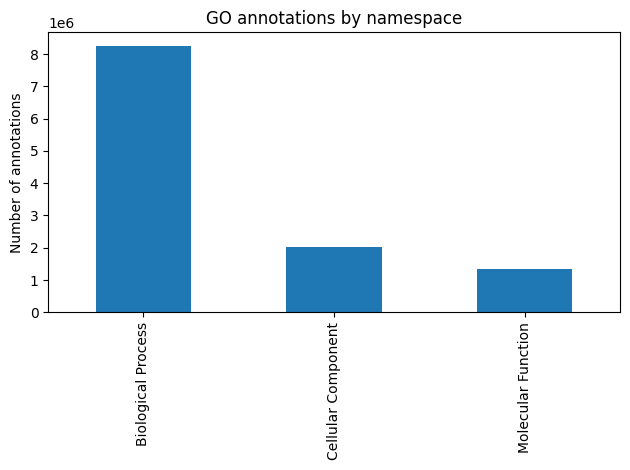

In [52]:
import matplotlib.pyplot as plt

namespace_counts.plot(
    x="namespace",
    y="n_annotations",
    kind="bar",
    legend=False
)

plt.ylabel("Number of annotations")
plt.xlabel("")
plt.title("GO annotations by namespace")
plt.tight_layout()
plt.show()

### 5. How many unique GO terms are present in the combined dataset?


In [54]:
df_filtered.groupby("namespace")["go_id"].nunique()

namespace
Biological Process    14080
Cellular Component     1793
Molecular Function     4197
Name: go_id, dtype: int64

In [55]:
#How many unique GO terms are present in the combined dataset?
df_filtered['GO_ID'].nunique()

20070

### 6. Which GO terms are most frequently observed?

In [56]:
# Which GO terms are most frequently observed?

tmp_df = df_filtered.groupby('GO_ID').size().\
reset_index(name='count').\
sort_values(by='count', ascending=False)[:10]
tmp_df['GO_name'] = tmp_df['GO_ID'].apply(lambda x: go[x].name)
tmp_df

,GO_ID,count,GO_name
2554,GO:0005575,113179,cellular_component
3755,GO:0008150,111879,biological_process
2585,GO:0005622,97546,intracellular anatomical structure
4455,GO:0009987,97094,cellular process
1548,GO:0003674,95660,molecular_function
10394,GO:0043226,85505,organelle
10397,GO:0043229,83619,intracellular organelle
14354,GO:0065007,80946,biological regulation
2636,GO:0005737,80160,cytoplasm
10395,GO:0043227,77428,membrane-bounded organelle
